# Modelo Preditivo da Bolsa de Valores

O objetivo deste trabalho é desenvolver um modelo preditivo utilizando dados do IBOVESPA (Bolsa de Valores), com o foco em criar uma série temporal capaz de prever o fechamento diário do índice, buscando uma acurácia superior a 70%. Para identificar o modelo mais adequado, serão realizadas etapas como tratamento de dados, análise exploratória, verificação de outliers, análise de tendências e decomposição da série temporal. A decomposição permitirá identificar componentes como tendência, sazonalidade e ruído, além de coeficientes de autoregressão e diferenciação.

Posteriormente, será feita a modelagem e o treinamento dos modelos de Machine Learning, com o intuito de comparar o desempenho de cada um. Os modelos que serão avaliados incluem o XGBoost, conhecido por sua eficiência em dados estruturados; o Prophet, um modelo de série temporal desenvolvido pelo Facebook para capturar tendências e sazonalidades; o SARIMAX, que incorpora componentes de sazonalidade e é ideal para séries temporais com padrões sazonais; e o LSTM, uma rede neural projetada para capturar dependências de longo prazo em dados sequenciais, como séries temporais. Após a avaliação de cada modelo, será selecionado aquele que oferecer a melhor precisão e confiabilidade para a previsão dos valores futuros do IBOVESPA.

# 1. Bibliotecas

1.1 Importação de Bibliotecas:
Segue abaixo as bibliotecas que serão usadas e suas principais funcionalidades:
- matplotlib: Usada para criar gráficos e visualizações.
- numpy: Utilizada para manipulação de arrays e operações matemáticas.
- pandas: Utilizada para manipulação e análise de dados.
- statsmodels: Fornece ferramentas para análise estatística e econometria.
- xgboost: Algoritmo eficiente de boosting, comumente usado para problemas de machine learning.
- yfinance: Biblioteca para baixar dados financeiros, como o usado para coletar o Ibovespa.
- pmdarima: Focada em modelagem de séries temporais, especialmente para automação de ARIMA.
- prophet: Modelo desenvolvido pelo Facebook para previsão de séries temporais.
- sklearn (scikit-learn): Biblioteca fundamental para machine learning.

In [ ]:
#!pip install matplotlib==3.3.4
#!pip install numpy==1.22.4
#!pip install pandas==2.0.3
#!pip install statsmodels==0.14.1
#!pip install xgboost==2.1.1
#!pip install yfinance==0.2.44
!pip install pmdarima==2.0.4
#!pip install prophet==1.1.6
#!pip install scikit-learn==0.24.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.6 MB/s eta 0:00:00


In [ ]:
import matplotlib
import numpy
import pandas
import statsmodels
import xgboost
import yfinance
import pmdarima
import prophet
import sklearn
import plotly.graph_objects

print(f"""
-- Versões Bibliotecas --
matplotlib: {matplotlib.__version__}   numpy: {numpy.__version__}
pandas: {pandas.__version__}   statsmodels: {statsmodels.__version__}
xgboost: {xgboost.__version__}   yfinance: {yfinance.__version__}
pmdarima: {pmdarima.__version__}   prophet: {prophet.__version__}
sklearn: {sklearn.__version__}
""")



-- Versões Bibliotecas --
matplotlib: 3.7.1   numpy: 1.26.4
pandas: 2.2.2   statsmodels: 0.14.4
xgboost: 2.1.1   yfinance: 0.2.44
pmdarima: 2.0.4   prophet: 1.1.6
sklearn: 1.5.2



In [ ]:
# Renomeando bibliotecas para facilitar uso
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import xgboost as xgb
import yfinance as yf
import pmdarima as pm
import plotly.graph_objects as go
from prophet import Prophet
from statsmodels.graphics.tsaplots import plot_acf as _plot_acf
from statsmodels.graphics.tsaplots import plot_pacf as _plot_pacf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
# Ignorando mensagens de atenção
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore")

# 2. Definindo Métricas para Avaliação de Modelos

Abaixo será definido uma função com intuito de facilitar o cálculo das métricas de avaliação de cada modelo, dessa forma será possível determinar qual modelo apresentou melhor desempenho.
Para fins de avaliação será usado o MAE, MSE e MAPE:
- MAE (Mean Absolute Error): Calcula o erro absoluto médio entre os valores reais e previsões, assim será possível entender o quanto as previsões estão distantes dos valores reais.Quanto menor o MAE, mais preciso é o modelo.

- MSE (Mean Squared Error): Calcula o erro quadrático médio, aqui quanto maior o erro, maior será o impacto no cálculo, pois os grandes erros são mais penalizados com as diferenças as quadrado.

- MAPE (Mean Absolute Percentage Error): Calcula a diferença entre os valores reais e os valores previstos, expressando o erro como uma porcentagem dos valores reais. Valores menores de MAPE indicam que o modelo de previsão é mais preciso, enquanto valores maiores indicam menos precisão. Por exemplo, um MAPE de 5% significa que, em média, as previsões estão 5% distantes dos valores reais.

In [ ]:
# Função para calcular métricas de avaliação
def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    return mae, mse, mape


# Função para imprimir as métricas de avaliação
def print_metrics(metrics):

    mae, mse, mape = metrics

    print(f"MAE: {mae}")

    print(f"MSE: {mse}")

    print(f"MAPE: {mape:.2f} %")


# 3. Importação dos Dados

Nesta etapa, serão importados dados históricos da bolsa de valores usando a biblioteca yfinance, desde 02/01/1994 até 10/10/2024. Serão selecionados apenas os dados mais relevantes, como data, valores de abertura e fechamento, para focar na análise das variações diárias do mercado.

In [ ]:
# Baixando os dados do Ibovespa
ticker = "^BVSP"
data = yf.download(ticker, start="1994-01-02", end="2024-10-10")
data = data[["Open", "Close"]] #Selecionando apenas os valores de abertura e fechamento
data.reset_index(inplace=True)
data["Date"] = pd.to_datetime(data["Date"])


[*********************100%***********************]  1 of 1 completed


In [ ]:
# Visualizando os primeiros registros
print("Primeiros dados:")
print(data.head())

Primeiros dados:
        Date        Open       Close
0 1994-01-03  375.500000  380.100006
1 1994-01-04  380.100006  400.600006
2 1994-01-05  400.600006  421.100006
3 1994-01-06  421.100006  444.200012
4 1994-01-07  444.200012  476.399994


In [ ]:
# Visualizando os últimos registros
print("Últimos dados:")
print(data.tail())

Últimos dados:
           Date      Open     Close
7613 2024-10-03  133514.0  131672.0
7614 2024-10-04  131672.0  131792.0
7615 2024-10-07  131792.0  132018.0
7616 2024-10-08  132016.0  131512.0
7617 2024-10-09  131510.0  129962.0


# 4. Análise Exploratória (EDA)

A seguir, será realizada a análise exploratória dos dados, começando pela verificação dos tipos de dados e a identificação de valores ausentes ou duplicados, que, caso existam, serão excluídos para não comprometer a análise. Em seguida, será apresentada uma descrição resumida dos dados, além da análise de outliers e da variação dos valores ao longo dos últimos 30 anos.

In [ ]:
# Verificar tipos de dados
print(data.dtypes)


Date     datetime64[ns]
Open            float64
Close           float64
dtype: object


In [ ]:
# Verificar a quantidade de valores ausentes em cada coluna
print(data.isnull().sum())


Date     0
Open     0
Close    0
dtype: int64


In [ ]:
# Verificar se há linhas duplicadas
duplicates = data[data.duplicated()]
print(duplicates)


Empty DataFrame
Columns: [Date, Open, Close]
Index: []


In [ ]:
# Exibir estatísticas descritivas do DataFrame
print(data.describe())


                                Date           Open          Close
count                           7618    7618.000000    7618.000000
mean   2009-05-27 17:19:15.893935104   49960.045222   49971.569612
min              1994-01-03 00:00:00     375.500000     380.100006
25%              2001-09-17 06:00:00   13622.250000   13622.250000
50%              2009-05-26 12:00:00   50163.500000   50179.000000
75%              2017-02-06 18:00:00   68863.750000   68902.750000
max              2024-10-09 00:00:00  137349.000000  137344.000000
std                              NaN   37123.430174   37134.398086


#4.1 Outliers

Outliers, ou valores atípicos, são pontos de dados que se desviam significativamente do restante das observações em um conjunto de dados. Eles podem indicar variabilidade incomum, erros de medição ou fenômenos raros. A identificação de outliers é crucial, pois podem distorcer análises estatísticas, afetando médias e variâncias e, consequentemente, levando a conclusões erradas.

Neste tópico, será analisada a existência de outliers nos dados de abertura ("Open") e fechamento ("Close") do Ibovespa, utilizando o método do Intervalo Interquartil (IQR) para estabelecer limites que definem quais valores são considerados atípicos. Com base nesses limites, será possível identificar e calcular a porcentagem de outliers em relação ao conjunto de dados analisado.

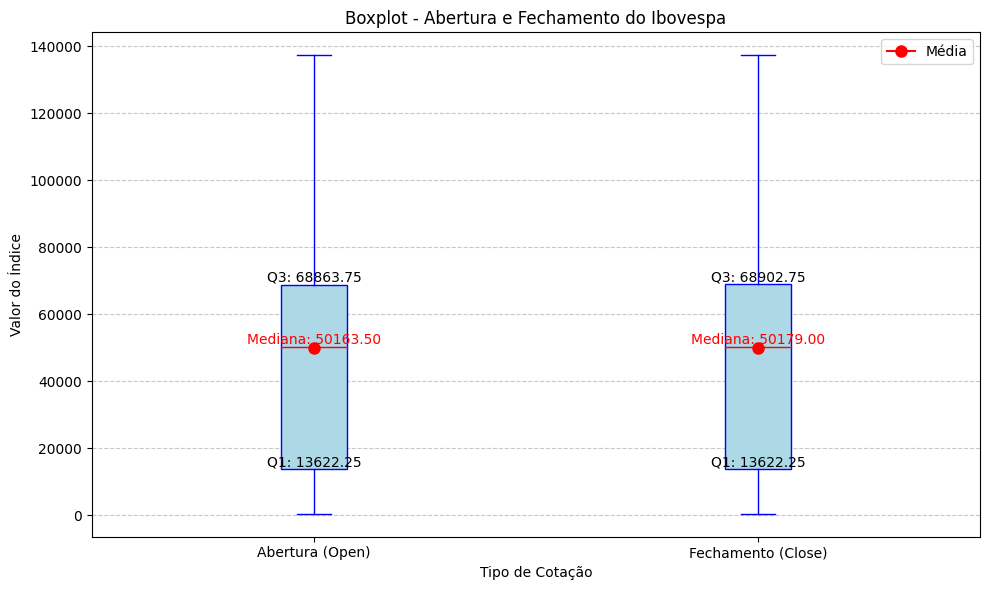

In [ ]:
# Limpando as colunas com valores NAN
datav = [data['Open'].dropna(), data['Close'].dropna()]

# Boxplot
plt.figure(figsize=(10, 6))
box = plt.boxplot(datav, patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'),
                  medianprops=dict(color='red'), whiskerprops=dict(color='blue'),
                  capprops=dict(color='blue'), flierprops=dict(markerfacecolor='red', marker='o'))

# Títulos Gráfico
plt.xticks([1, 2], ['Abertura (Open)', 'Fechamento (Close)'])
plt.ylabel('Valor do Índice')
plt.xlabel('Tipo de Cotação')

# Adicionando linhas para a média
for i, data_set in enumerate(datav, start=1):
    mean = np.mean(data_set)
    plt.plot(i, mean, marker='o', color='red', markersize=8, label='Média' if i == 1 else "")

    # Calculando Q1, Q2 (mediana) e Q3
    Q1 = np.percentile(data_set, 25)
    median = np.median(data_set)
    Q3 = np.percentile(data_set, 75)

    # Adicionando os valores no gráfico
    plt.text(i, Q1, f'Q1: {Q1:.2f}', horizontalalignment='center', verticalalignment='bottom', fontsize=10)
    plt.text(i, median, f'Mediana: {median:.2f}', horizontalalignment='center', verticalalignment='bottom', fontsize=10, color='red')
    plt.text(i, Q3, f'Q3: {Q3:.2f}', horizontalalignment='center', verticalalignment='bottom', fontsize=10)

# Título princiapl
plt.title("Boxplot - Abertura e Fechamento do Ibovespa")
plt.legend()  # Adicionar legenda

# Exibir o gráfico
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
#Definindo função para calcular percentual de outliers
def calcular_outliers_percentual(dados):

    dados_limpos = dados.dropna()

    # Calculando quartis
    Q1 = np.percentile(dados_limpos, 25)
    Q3 = np.percentile(dados_limpos, 75)
    IQR = Q3 - Q1

    # Calculando os limites para outliers
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Exibir os valores de Q1, Q3, IQR e os limites
    print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}')
    print(f'Limite Inferior: {limite_inferior}, Limite Superior: {limite_superior}')

    # Contando outliers
    outliers = dados_limpos[(dados_limpos < limite_inferior) | (dados_limpos > limite_superior)]

    # Calculando percentual de outliers
    percentual_outliers = (len(outliers) / len(dados_limpos)) * 100

    return percentual_outliers

Abaixo foi identificado que para os valores de abertura, o primeiro quartil (Q1) foi de 13.622,25, e o terceiro quartil (Q3) foi de 68.863,75, resultando em um intervalo interquartil (IQR) de 55.241,50. Os limites inferior e superior, calculados com base no IQR, foram de -69.240,00 e 151.726,00, respectivamente. Não foram identificados outliers, com percentual de 0,00%.  

No caso dos valores de fechamento, os resultados foram semelhantes, com Q1 em 13.622,25, Q3 em 68.902,75, e IQR de 55.280,50. Os limites inferior e superior foram de -69.298,50 e 151.823,50, respectivamente. Assim como nos dados de abertura, o percentual de outliers também foi de 0,00%.

Portanto, os resultados obtidos indicam que, tanto nos dados de abertura quanto nos de fechamento, não existem valores atípicos que possam distorcer a análise estatística. A ausência de outliers sugere que os dados são consistentes e refletem uma variação controlada ao longo do período analisado.

In [ ]:
# Calculando o percentual dos valores de abertura
percentual_outliers_open = calcular_outliers_percentual(data['Open'])
print(f'Percentual de outliers em Open: {percentual_outliers_open:.2f}%','\n')

# Calculando o percentual dos valores de fechamento
percentual_outliers_close = calcular_outliers_percentual(data['Close'])
print(f'Percentual de outliers em Close: {percentual_outliers_close:.2f}%')

Q1: 13622.25, Q3: 68863.75, IQR: 55241.5
Limite Inferior: -69240.0, Limite Superior: 151726.0
Percentual de outliers em Open: 0.00% 

Q1: 13622.25, Q3: 68902.75, IQR: 55280.5
Limite Inferior: -69298.5, Limite Superior: 151823.5
Percentual de outliers em Close: 0.00%


#4.2 Análise de Tendências

No gráfico acima, observa-se que as linhas de fechamento e abertura do Ibovespa mantêm-se próximas ao longo dos últimos 30 anos, indicando uma relação consistente entre esses indicadores. A tendência geral é de crescimento, refletindo um aumento no valor das ações e um otimismo em relação à economia brasileira. No entanto, momentos de queda significativos foram registrados, como em 2008 e 2020.

A queda de 2008 foi provocada pela crise financeira global, que impactou severamente os mercados e levou investidores a buscarem ativos mais seguros. Já a queda em 2020 resultou da pandemia de COVID-19, que gerou incertezas econômicas e desregulou diversas indústrias.

Além desses eventos, a trajetória do Ibovespa é influenciada por fatores como a política monetária (taxa de juros), o ambiente político (eleições e reformas), flutuações no câmbio e commodities, e eventos externos que podem afetar a percepção de risco.

Portanto, a análise do Ibovespa destaca uma tendência de crescimento ao longo do tempo, bem como a complexidade dos fatores que influenciam a bolsa brasileira, evidenciando sua resiliência diante de crises e volatilidades.

In [ ]:
# Calculando mínimo e máximo
min_price = min(data["Open"].min(), data["Close"].min())
max_price = max(data["Open"].max(), data["Close"].max())

# Criando figura
fig = go.Figure()

# Adicionando traço para o preço de fechamento
fig.add_trace(go.Scatter(x=data["Date"], y=data["Close"], mode='lines+markers', name='Preço de Fechamento',
                         line=dict(color='blue', width=2), marker=dict(size=4)))

# Adicionando traço para o preço de abertura (com deslocamento)
fig.add_trace(go.Scatter(x=data["Date"], y=data["Open"] + 1000, mode='lines+markers', name='Preço de Abertura',
                         line=dict(color='red', width=2), marker=dict(size=4)))

# Adicionando linha de mínimo
fig.add_trace(go.Scatter(x=data["Date"], y=[min_price] * len(data), mode='lines', name='Mínimo',
                         line=dict(color='black', dash='dash')))

# Adicionar linha de máximo
fig.add_trace(go.Scatter(x=data["Date"], y=[max_price] * len(data), mode='lines', name='Máximo',
                         line=dict(color='purple', dash='dash')))

# Identificando e adicionando pontos de alta e baixa
highs = data[data['Close'] == data['Close'].max()]
lows = data[data['Close'] == data['Close'].min()]

# Adicionando pontos de alta e baixa
fig.add_trace(go.Scatter(x=highs["Date"], y=highs["Close"], mode='markers', name='Ponto Máximo',
                         marker=dict(color='purple', size=10, symbol='star')))

fig.add_trace(go.Scatter(x=lows["Date"], y=lows["Close"], mode='markers', name='Ponto Mínimo',
                         marker=dict(color='black', size=10, symbol='x')))

# Configurações do layout
fig.update_layout(title="Valores de Abertura e Fechamento ao Longo dos últimos 30 anos",
                  xaxis_title="Anos",
                  yaxis_title="Valores",
                  legend=dict(x=0.1, y=0.9),
                  template='plotly_white')

# Mostrando gráfico
fig.show()


# 5. Série Temporal

Abaixo será realizado a decomposição da série temporal, que basicamente é uma técnica que permite analisar as diferentes componentes de uma série ao longo do tempo, facilitando a interpretação e modelagem dos dados. As principais componentes incluem:

- Tendência (Trend): A direção de longo prazo da série, que pode ser crescente, decrescente ou estável.

- Sazonalidade (Seasonality): Padrões que se repetem em intervalos regulares, como variações mensais ou anuais, influenciados por fatores como clima ou feriados.

- Ciclos (Cycles): Flutuações na série que ocorrem em períodos irregulares, muitas vezes relacionadas a fatores econômicos.

- Resíduos (Residuals): Variações aleatórias que não podem ser atribuídas às outras componentes, representando o "ruído" da série.

#5.1 Decomposição Multiplicativa

Neste tipo de decomposição, a série é expressa como o produto de suas componentes (tendência, sazonalidade e resíduos). Isso é apropriado quando a amplitude das variações sazonais aumenta com o tempo. Aqui definiremos o período da sazonalidade como anual para o valor de fechamento, visto que é uma base diária.



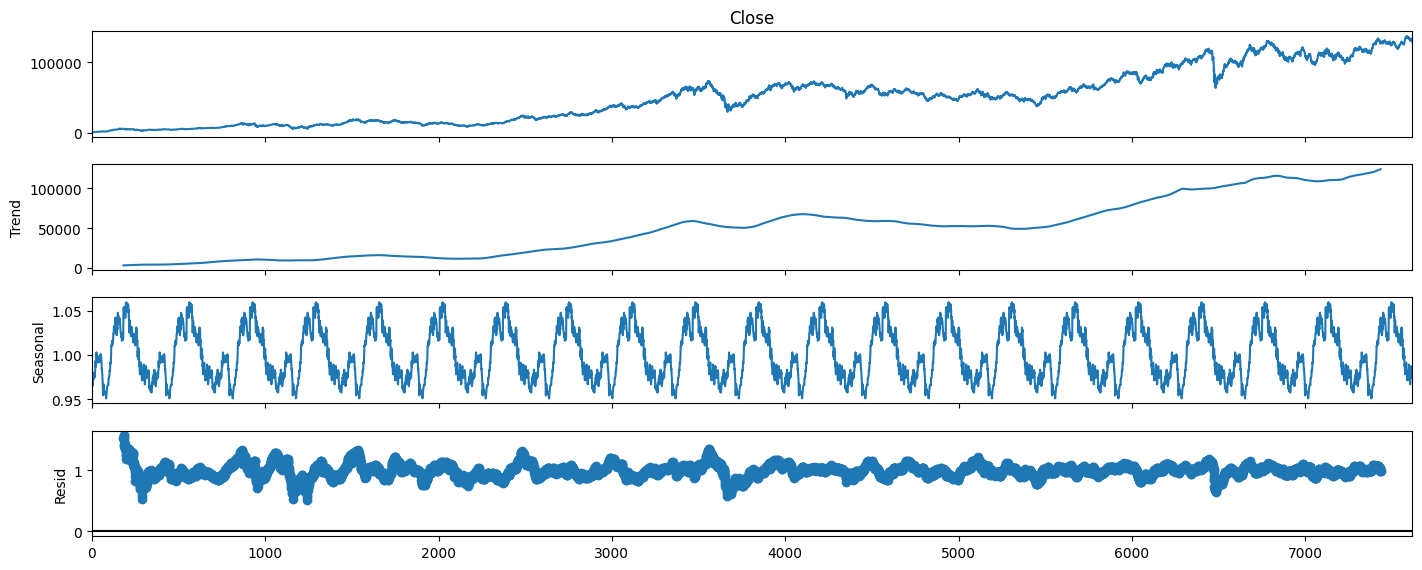

In [ ]:
#Realizando decomposição
result = seasonal_decompose(data["Close"], model="multiplicative", period=365)
fig = result.plot()
fig.set_size_inches(16, 6)

Quando são selecionados os primeiros 500 pontos da sazonalidade, conforme o gráfico abaixo, é possível perceber de forma mais clara os padrões sazonais que se manifestam ao longo do tempo. Essa visualização facilita a identificação de flutuações regulares nos preços do Ibovespa, permitindo observar como esses preços tendem a aumentar ou diminuir em determinados períodos.

Nota-se que, no início, há uma leve alta seguida por uma queda acentuada entre aproximadamente os dias 60 e 90. Após esse período de declínio, os preços novamente apresentam um crescimento consistente, com quedas leves ao longo do caminho. Perto do final do período analisado, aproximadamente 100 dias antes do final do ano, observa-se mais uma queda nos preços que só é recuperada novamente no início do ano.

<Axes: >

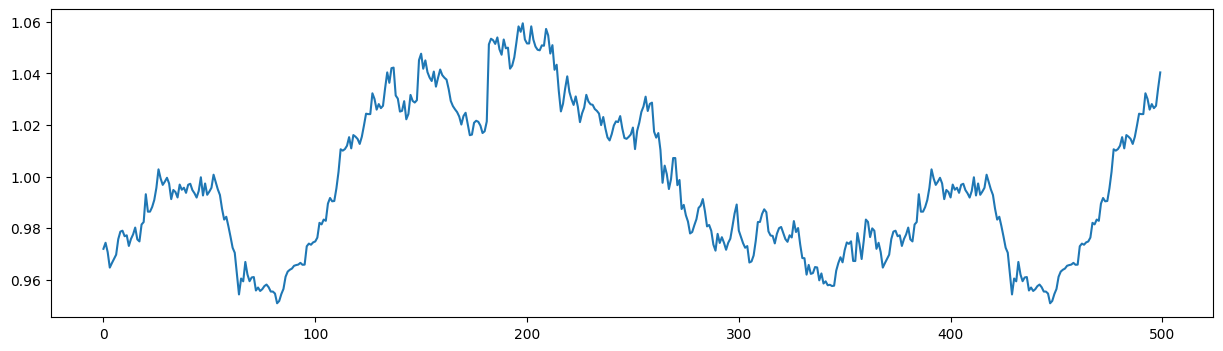

In [ ]:
result.seasonal.iloc[:500].plot(figsize=(15, 4))

#5.2 Decomposição Aditiva

A decomposição aditiva é uma técnica utilizada em análise de séries temporais para separar uma série em suas componentes principais: tendência, sazonalidade e resíduos. Este método é apropriado quando as variações sazonais e os resíduos não aumentam com o tempo, ou seja, a amplitude das flutuações não é proporcional ao nível da série.

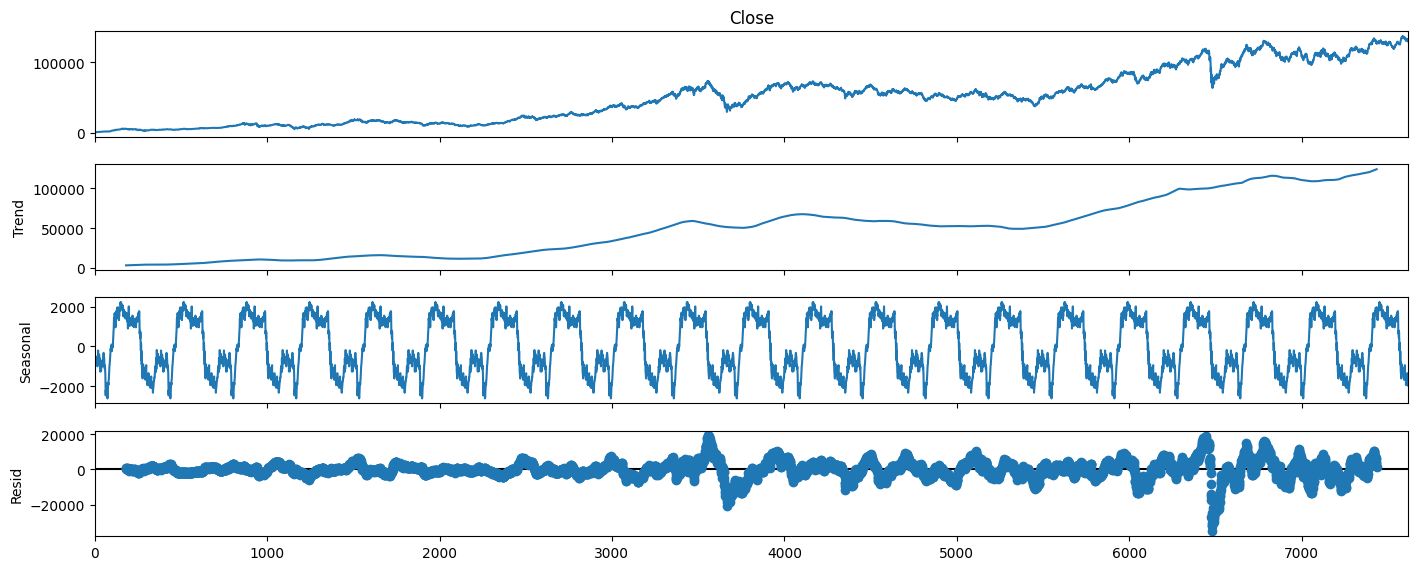

In [ ]:
# Realizando Decomposição Aditiva
result = seasonal_decompose(data["Close"], model="additive", period=365)
fig = result.plot()
fig.set_size_inches(16, 6)

#5.3 Decomposição Autoregressiva
A decomposição autoregressiva é uma técnica que separa uma série temporal em componentes distintas, como tendência, sazonalidade e resíduos, utilizando modelos que consideram a dependência temporal dos dados. Isso permite entender como os valores passados da série influenciam os valores atuais e futuros, facilitando a previsão e análise de padrões.

#5.3.1 Auto correlação (ACF)

Com o objetivo de encontrar os coeficientes de intercepção da ACF (Autocorrelation Function) e comparar a funcionalidade dos modelos de previsão, será utilizado os dados dos últimos 10 anos. Aqui foi obtido o ACF = 244.

In [ ]:
# Convertendo a coluna 'Date' para o tipo datetime, se ainda não estiver
data['Date'] = pd.to_datetime(data['Date'])

# Definindo a coluna 'Date' como índice
data.set_index('Date', inplace=True)

# Realizando o corte dos últimos 10 anos
data1 = data['2014-01-02':'2024-09-10']


In [ ]:
# Realizando corte dos últimos 10 anos
data1 = data['2014-01-02':'2024-09-10']

In [ ]:
#Definindo função acf
def plot_acf(data1, lags=365, title="Autocorrelação da Série Temporal"):

    fig, ax = plt.subplots(figsize=(15, 5))

    _plot_acf(data1, lags=lags, ax=ax, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel("Lags")
    ax.set_ylabel("Autocorrelação")
    fig.set_tight_layout(True)

    acf_x = sm.tsa.acf(data1, alpha=0.05, nlags=365)
    acf, ci = acf_x[:2]
    intercept_point = np.where(abs(acf) < (ci[:, 1] - acf))
    if intercept_point[0].size > 0:
        print(
            f"Os coeficientes da ACF interceptam o limite em lag {intercept_point[0][0]}"
        )
    else:
        print("Os coeficientes da ACF não interceptam o limite")

Os coeficientes da ACF interceptam o limite em lag 244


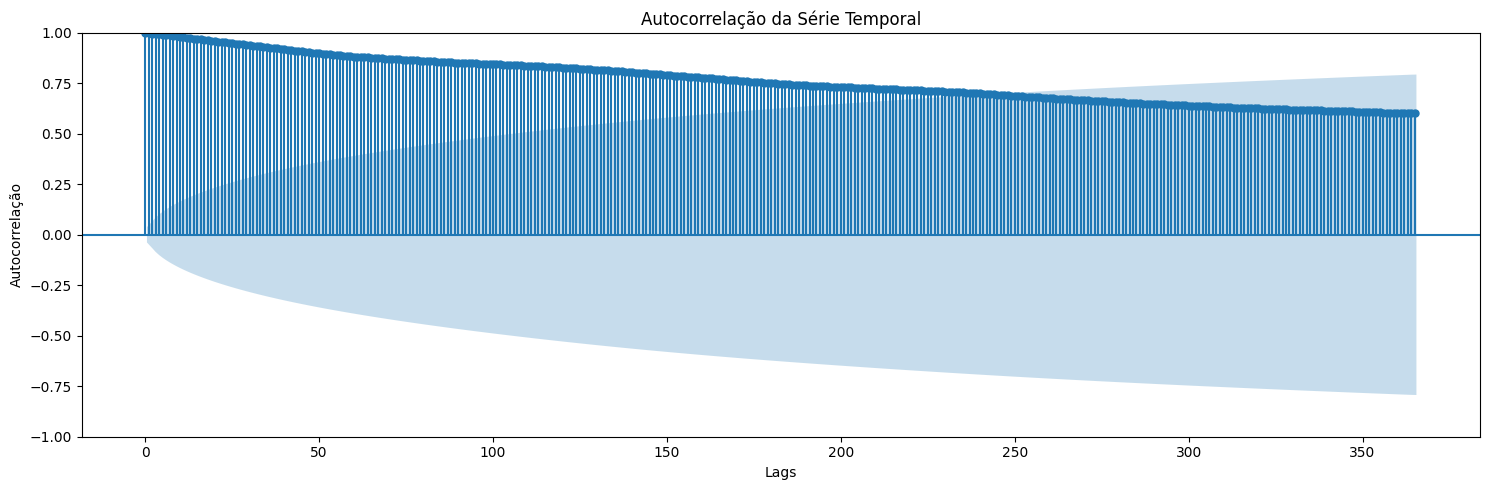

In [ ]:
plot_acf(data1["Close"])

#5.3.2 Auto correlação parcial (PACF)

Autocorrelação Parcial (PACF) é uma técnica estatística que mede a correlação entre uma série temporal e suas próprias defasagens (lags), controlando para as defasagens intermediárias. Em outras palavras, enquanto a autocorrelação simples mede a relação linear entre a série e suas defasagens, a PACF identifica a correlação direta de um lag específico, removendo a influência de outros lags.

A PACF é usada na modelagem de séries temporais, especialmente na identificação de ordens de modelos AR (autoregressivos) no contexto da modelagem ARIMA. Aqui foi obtido o PACF = 3.

In [ ]:
# Definindo o pacf

def plot_pacf(data1, lags=30, title="Autocorrelação Parcial da Série Temporal"):

    fig, ax = plt.subplots(figsize=(15, 5))

    _plot_pacf(data1, lags=lags, ax=ax, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel("Lags")
    ax.set_ylabel("Autocorrelação Parcial")
    fig.set_tight_layout(True)

    acf_x = sm.tsa.pacf(data1, alpha=0.05, nlags=lags)
    acf, ci = acf_x[:2]
    intercept_point = np.where(abs(acf) < (ci[:, 1] - acf))
    if intercept_point[0].size > 0:
        print(
            f"Os coeficientes da PACF interceptam o limite em lag {intercept_point[0][0]}"
        )
    else:
        print("Os coeficientes da PACF não interceptam o limite")

Os coeficientes da PACF interceptam o limite em lag 3


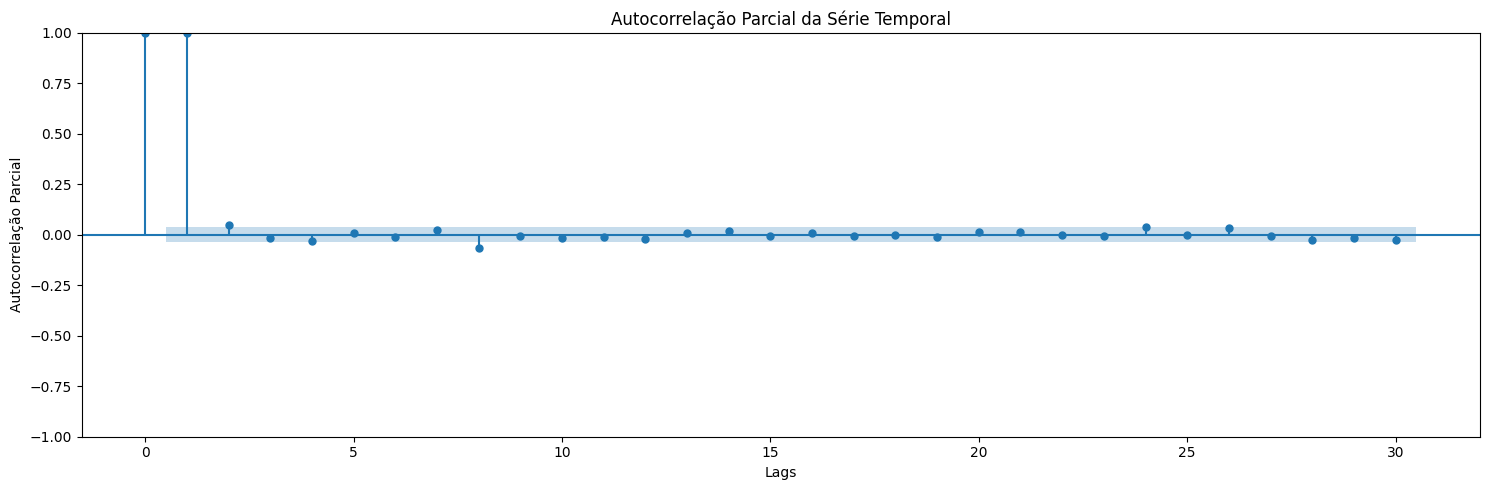

In [ ]:
plot_pacf(data1["Close"])

#5.3.3 Diferenciação para estacionariedade (ADF)

A diferenciação é uma técnica utilizada para transformar uma série temporal não estacionária em estacionária, o que significa que suas propriedades, como média e variância, permanecem constantes ao longo do tempo. Muitos modelos de previsão, como os modelos autoregressivos (AR), exigem que a série seja estacionária para funcionarem corretamente. Inicialmente, será verificado se a série original é estacionária. Caso não seja, será aplicado o método de diferenciação para remover tendências, e em seguida, será verificado se a série se tornou estacionária após o processamento.

In [ ]:
adf_result = sm.tsa.adfuller(data1["Close"])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("A série temporal é estacionária")
else:
    print("A série temporal não é estacionária")

ADF Statistic: -1.038513457149343
p-value: 0.7389596014417718
Critical Values: {'1%': -3.4328256656870946, '5%': -2.8626337621365936, '10%': -2.567352247505842}
A série temporal não é estacionária


Com os resultados do teste ADF acima, onde o ADF Statistic é -1.0385, maior que os valores críticos, e o p-valor de 0.7389 é superior a 0.05, conclui-se que a série não é estacionária. Isso indica que a série ainda possui tendência ou variação ao longo do tempo.

No gráfico que abaixo é possível ver as flutuações diárias do preço de fechamento do ativo, assim como o comportamento da série temporal. A série não apresenta um comportamento constante ao longo do tempo, possivelmente devido à presença de tendências ou variações sazonais como previsto com os dados acima.

<Axes: xlabel='Date'>

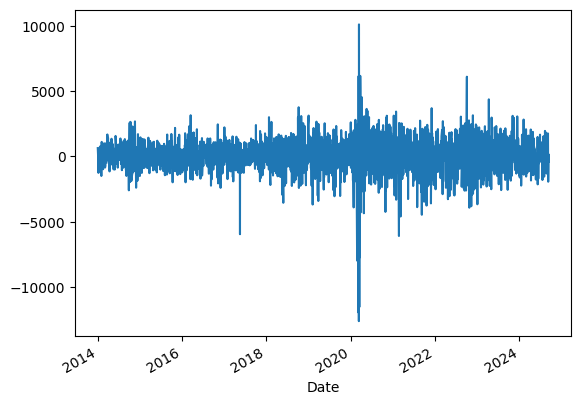

In [ ]:
data1["Close"].diff().plot()

Quando é aplicado a primeira diferenciação, os resultados obtidos indicam que a série temporal tornou-se estacionaria, ou seja, com média e variância constantes ao longo do tempo.

In [ ]:
# Diferenciando 1 vez

adf_result = sm.tsa.adfuller(data1["Close"].diff().dropna())
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("A série temporal é estacionária")
else:
    print("A série temporal não é estacionária")

ADF Statistic: -17.987290888418922
p-value: 2.761917603075696e-30
Critical Values: {'1%': -3.4328256656870946, '5%': -2.8626337621365936, '10%': -2.567352247505842}
A série temporal é estacionária


#5.3.4 Coeficientes de autoregressão

Abaixo será calculado os coeficientes de autocorrelação (ACF) e autocorrelação parcial (PACF) para determinar os parâmetros de um modelo ARIMA, especificamente p (para autoregressão) e q (para média móvel). A diferenciação (d) aplicada acima é usada para garantir que a série seja estacionária, o que é essencial para a aplicação de modelos ARIMA.

In [ ]:
acf_x = sm.tsa.acf(data1["Close"], alpha=0.05, nlags=365)
acf, ci = acf_x[:2]
# identificação do q pelo ponto de interceptação ao 95% com o acf
q = np.where(abs(acf) < (ci[:, 1] - acf))[0][0]

pacf_x = sm.tsa.pacf(data1["Close"], alpha=0.05, nlags=30)
pacf, ci = pacf_x[:2]
# identificação do p pelo ponto de interceptação ao 95% com o pacf
p = np.where(abs(pacf) < (ci[:, 1] - pacf))[0][0]

d = 1  # apenas 1 diferenciação foi necessária para tornar a série estacionária

Portanto, os coeficientes obtidos foram p = 3 , q = 244 e d = 1.

In [ ]:
# parâmetros do modelo ARIMA
p, q, d

(3, 244, 1)

#5.3.5 Determinando os parâmetros de sazonalidade

Abaixo será realizada a modelagem da série temporal de preços de fechamento, identificando automaticamente os melhores parâmetros para um modelo ARIMA sazonal e fornece um resumo dos resultados do ajuste do modelo. Foi definido a periodicidade sazonal de forma mensal, ou seja, o modelo considerará uma sazonalidade de 12 meses.

In [ ]:
model = pm.auto_arima(
    data1["Close"],
    seasonal=True,
    m=12,
    stepwise=True,
)

# Resumo dos parâmetros detectados pelo modelo
print(model.summary())

# Ordem sazonal detectada
seasonal_order = model.seasonal_order
print(f"Ordem Sazonal Detectada: {seasonal_order}")


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2652
Model:               SARIMAX(3, 1, 2)   Log Likelihood              -22723.042
Date:                Tue, 15 Oct 2024   AIC                          45458.084
Time:                        21:47:40   BIC                          45493.380
Sample:                             0   HQIC                         45470.860
                               - 2652                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.6317      0.091    -18.007      0.000      -1.809      -1.454
ar.L2         -0.8069      0.097     -8.294      0.000      -0.998      -0.616
ar.L3         -0.0133      0.015     -0.915      0.3

# 6. Organizando Dados em Treino e Teste para Análise

In [ ]:
# Dividindo em treino e teste
train_size = data1.shape[0] - 7  # Define o tamanho do conjunto de treinamento, excluindo os últimos 7 dias.
train, test = data1[:train_size], data1[train_size:]  # Divide o DataFrame em conjunto de treino e teste.


In [ ]:
# Resetando o índice para que 'Date' se torne uma coluna
data1.reset_index(inplace=True)

In [ ]:
data1.head()

,level_0,index,Date,Open,Close
0,0,0,2014-01-02,51522.0,50341.0
1,1,1,2014-01-03,50348.0,50981.0
2,2,2,2014-01-06,50980.0,50974.0
3,3,3,2014-01-07,50982.0,50430.0
4,4,4,2014-01-08,50431.0,50577.0


In [ ]:
# Preparação dos dados para XGBoost
def create_features(df):
    df["Date"] = pd.to_datetime(df["Date"])
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["day"] = df["Date"].dt.day
    df["dayofweek"] = df["Date"].dt.dayofweek
    return df


train = create_features(train)
test = create_features(test)

FEATURES = ["year", "month", "day", "dayofweek", "Open"]
TARGET = "Close"

# 6.1 Modelo XGBoost

O XGBoost é uma implementação otimizada do algoritmo de boosting de gradiente, que combina vários modelos de decisão fraca (árvores de decisão) para melhorar a precisão de previsões. É amplamente utilizado em tarefas de regressão e classificação devido à sua alta performance, flexibilidade, e capacidade de lidar com grandes volumes de dados.

O XGBoost, embora seja usado para dados tabulares, pode ser aplicado a séries temporais convertendo as datas em variáveis como ano, mês, dia e dia da semana. Observações passadas são usadas para prever valores futuros. Diferente de modelos como ARIMA e SARIMA, o XGBoost não capta automaticamente a dependência temporal, sendo necessário incorporar essa informação manualmente passando como parâmetro através da FEATURES e TARGET abaixo.

In [ ]:
# Modelo XGBoost
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

reg = xgb.XGBRegressor(objective="reg:squarederror")
reg.fit(X_train, y_train)

# Avaliação XGBoost
preds = reg.predict(X_test)
metrics_xgb = calculate_metrics(y_test, preds)
print("XGBoost Metrics:")
print_metrics(metrics_xgb)

XGBoost Metrics:
MAE: 2133.9754464285716
MSE: 6215043.157679967
MAPE: 1.57 %


Acuracidade do Modelo XGBoost é 98,43%.

In [ ]:
f"{100 - 1.57: .2f}%"

' 98.43%'

# 6.2 Modelo Prophet

O Prophet é uma biblioteca de previsão de séries temporais criada pelo Facebook, voltada para dados com padrões sazonais e tendências. É eficaz para dados com sazonalidade diária, semanal ou anual, e permite considerar feriados ou eventos que afetam as séries. Sua facilidade de uso e necessidade de poucos ajustes tornam o modelo acessível mesmo para iniciantes em estatística e ciência de dados.
Este modelo é capaz de captura de padrões identificando e modelando sazonalidades e tendências complexas nos dados. Além disso, lida bem com dados faltantes e outliers, e por fim gera previsões úteis para planejamento e tomada de decisões.

In [ ]:
# Modelo Prophet
train_prophet = train.rename(columns={"Date": "ds", "Close": "y"})
test_prophet = test.rename(columns={"Date": "ds", "Close": "y"})

model = Prophet(daily_seasonality=True)
model.add_regressor("Open")
model.fit(train_prophet)

future = model.make_future_dataframe(periods=len(test))
future["Open"] = pd.concat([train["Open"], test["Open"]], ignore_index=True)
forecast = model.predict(future)

preds = forecast[["ds", "yhat"]].tail(len(test))
preds = preds.set_index("ds")
y_test = test_prophet.set_index("ds")["y"]

metrics_pr = calculate_metrics(y_test, preds["yhat"])
print("Prophet Metrics:")
print_metrics(metrics_pr)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp98fyglmw/jzp8zh0l.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp98fyglmw/vxmc97gi.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=8924', 'data', 'file=/tmp/tmp98fyglmw/jzp8zh0l.json', 'init=/tmp/tmp98fyglmw/vxmc97gi.json', 'output', 'file=/tmp/tmp98fyglmw/prophet_model6wb8_0zu/prophet_model-20241015220114.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:01:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:01:16 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Prophet Metrics:
MAE: 1831.2633883737622
MSE: 5811216.4637794895
MAPE: 1.36 %


Acuracidade do Modelo Prophet é 98,64%.

In [ ]:
f"{100 - 1.36: .2f}%"

' 98.64%'

# 6.3 Modelo SARIMAX

O SARIMAX (Seasonal Autoregressive Integrated Moving Average with eXogenous variables) é um modelo de séries temporais que expande o ARIMA ao incluir:

- Autoregressivo (AR): Modela a dependência entre observações passadas.
- Integrado (I): Trata a não estacionaridade por meio de diferenciação.
- Média Móvel (MA): Relaciona observações a erros de previsões passadas.
- Sazonalidade: Captura padrões que se repetem em intervalos regulares.
- Exógenas (X): Permite a inclusão de variáveis externas que influenciam a série.

Essa combinação permite modelar séries temporais de forma mais flexível e precisa, especialmente em presença de sazonalidade e fatores externos. Abaixo será usado como fator externo o valor de abertura.

In [ ]:
p, d, q

(3, 1, 244)

In [ ]:
# Modelo SARIMAX
exog_train = train[["Open"]]
exog_test = test[["Open"]]

model = sm.tsa.statespace.SARIMAX(
    train["Close"],
    exog=exog_train,
    order=(
        p,
        d,
        1,
    ),
    seasonal_order=(0, 0, 0, 12),
)
results = model.fit()

preds = results.get_forecast(steps=len(test), exog=exog_test).predicted_mean

metrics_sarimax = calculate_metrics(test["Close"], preds)
print("SARIMAX Metrics:")
print_metrics(metrics_sarimax)

SARIMAX Metrics:
MAE: 1089.0679492995466
MSE: 1495393.1765945372
MAPE: 0.81 %


Acuracidade do Modelo SARIMAX é: 99,19%.

In [ ]:
f"{100 - 0.81: .2f}%"

' 99.19%'

#6.4 Modelo LSTM

O LSTM (Long Short-Term Memory) é uma rede neural recorrente (RNN) projetada para capturar dependências de longo prazo em séries temporais, mantendo informações por períodos prolongados. Ele se destaca em identificar tendências e padrões sazonais complexos, além de ser menos sensível a ruídos pontuais em comparação com modelos como ARIMA ou SARIMA.

In [ ]:
# Supondo que data1 é o seu DataFrame
data1 = data1[['Date', 'Open', 'Close']].copy()
data1['Date'] = pd.to_datetime(data1['Date'])
data1.set_index('Date', inplace=True)

# Normalização dos dados
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data1[['Close']])

# Dividindo os dados em conjuntos de treino e teste
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Função para criar as janelas de dados
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Criando as janelas de dados
time_step = 60  # Número de períodos para olhar para trás
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Reformatação dos dados para o formato [amostras, tempo, características]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Definindo o modelo LSTM
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Previsão de um único valor

# Compilando o modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Treinando o modelo
model.fit(X_train, y_train, epochs=50, batch_size=32)

# Fazendo previsões
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Invertendo a normalização para calcular as métricas
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Invertendo a normalização dos dados de teste
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0547
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0038
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0033
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0031
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0025
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0026
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0028
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0030
Epoch 9/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0024
Epoch 10/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0022
Epoch 11/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.0021
Epoch 12/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0025
Epoch 13/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0021
Epoch 14/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0019
Epoch 15/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0019
Epoc

In [ ]:
# Calculando as métricas para o LSTM
metrics_lstm = calculate_metrics(y_test_actual, test_predict)

# Imprimindo as métricas
print("LSTM Metrics:")
print_metrics(metrics_lstm)

LSTM Metrics:
MAE: 1840.0662898936175
MSE: 5106718.851596266
MAPE: 1.55 %


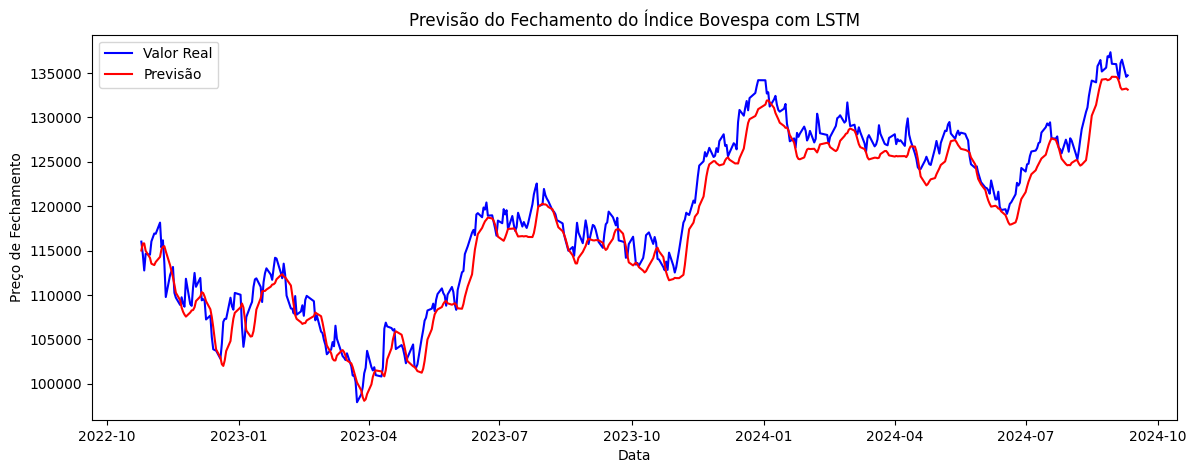

In [ ]:
# Visualizando os resultados
plt.figure(figsize=(14, 5))
plt.plot(data1.index[train_size + time_step + 1:], y_test_actual, color='blue', label='Valor Real')
plt.plot(data1.index[train_size + time_step + 1:], test_predict, color='red', label='Previsão')
plt.title('Previsão do Fechamento do Índice Bovespa com LSTM')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento')
plt.legend()
plt.show()

Acuracidade do Modelo LSTM é: 98,45%

In [ ]:
f"{100 - 1.55: .2f}%"

' 98.45%'

# 7. Comparando Modelos

In [ ]:
# Supondo que as métricas dos outros modelos já foram calculadas
df = pd.DataFrame(
    [metrics_xgb, metrics_pr, metrics_sarimax, metrics_lstm],
    columns=["MAE", "MSE", "MAPE"],
    index=["XGBoost", "Prophet", "SARIMAX", "LSTM"],
)

df.sort_values(by="MAPE", ascending=True)

# Exibindo o DataFrame ordenado
#print(df_sorted)


,MAE,MSE,MAPE
SARIMAX,1089.067949,1.495393e+06,0.808509
Prophet,1831.263388,5.811216e+06,1.357611
LSTM,1840.066290,5.106719e+06,1.545647
XGBoost,2133.975446,6.215043e+06,1.574832


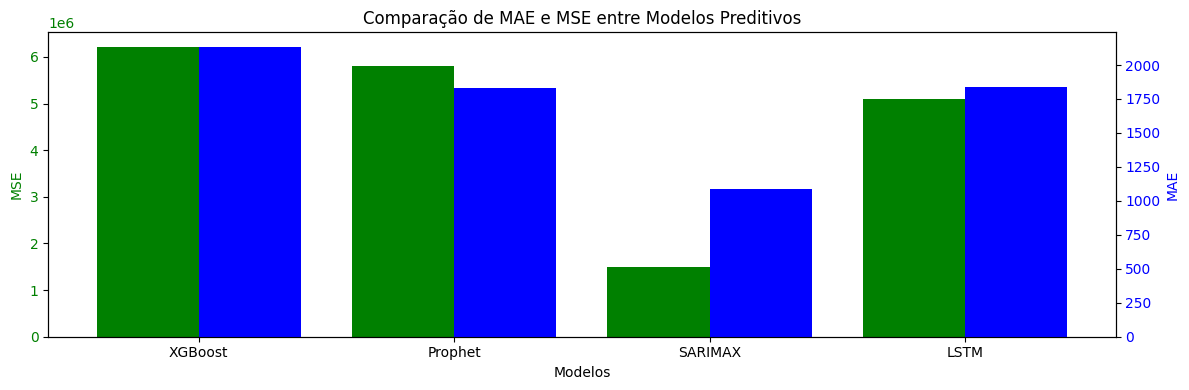

In [ ]:
# Largura das barras
bar_width = 0.4

# Posições das barras no eixo X
models = df.index
r1 = np.arange(len(models))
r2 = [x + bar_width for x in r1]

# Gráfico 1: Comparação de MAE e MSE com escalas separadas
fig, ax1 = plt.subplots(figsize=(12, 4))

# Plotar MSE no eixo da esquerda
ax1.set_xlabel('Modelos')
ax1.set_ylabel('MSE', color='g')
ax1.bar(r1, df['MSE'], color='g', width=bar_width, label='MSE')
ax1.tick_params(axis='y', labelcolor='g')

# Criar um segundo eixo Y para o MAE
ax2 = ax1.twinx()
ax2.set_ylabel('MAE', color='b')
ax2.bar(r2, df['MAE'], color='b', width=bar_width, label='MAE')
ax2.tick_params(axis='y', labelcolor='b')

# Ajustar os ticks do eixo X
plt.xticks([r + bar_width/2 for r in range(len(models))], models)

# Título e legendas
plt.title('Comparação de MAE e MSE entre Modelos Preditivos')
fig.tight_layout()

# Exibir o gráfico
plt.show()

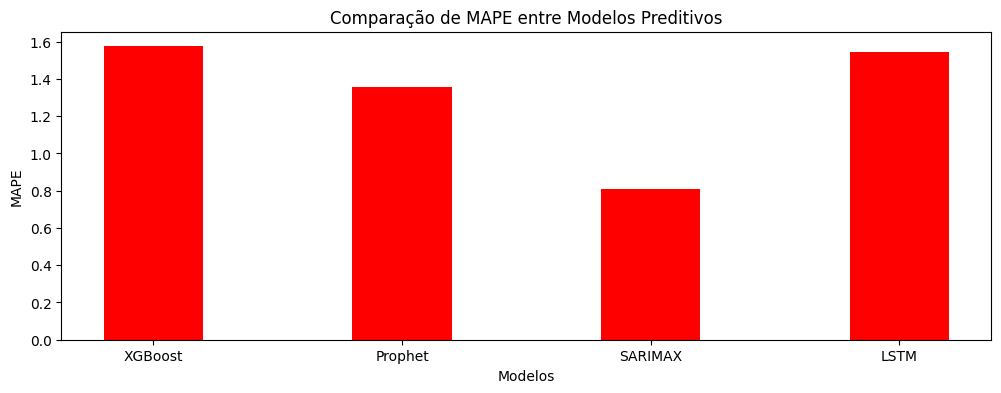

In [ ]:
# Criar o gráfico para MAPE
plt.figure(figsize=(12, 4))

# Gráfico exclusivo para MAPE
plt.bar(models, df['MAPE'], color='r', width=bar_width)

# Título e legendas
plt.title('Comparação de MAPE entre Modelos Preditivos')
plt.ylabel('MAPE')
plt.xlabel('Modelos')

# Exibir o gráfico
plt.show()

# 8. Conclusão

Com base nos resultados obtidos e analisando os gráficos acima, o modelo SARIMAX apresentou o melhor desempenho entre os modelos avaliados, com os menores valores de MAE (1089.07), MSE (1.495393e+06) e MAPE (0.8085), indicando uma maior precisão nas previsões do fechamento diário do IBOVESPA. O modelo Prophet, apesar de capturar bem sazonalidades, apresentou erros significativamente maiores, com MAE de 1831.26 e MAPE de 1.3576. O LSTM e o XGBoost tiveram desempenhos inferiores, com maiores erros preditivos, destacando-se o XGBoost, que apresentou o maior MAPE de 1.5748.

Portanto, o SARIMAX se mostrou o modelo mais adequado para essa série temporal, sendo o mais eficiente em capturar as características dos dados e fornecer previsões mais precisas. Assim, ele seria a escolha recomendada para a previsão do fechamento diário do índice IBOVESPA, atendendo aos critérios de acurácia e confiabilidade estabelecidos.